In [13]:
import cdsapi
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
import sys
from pathlib import Path
import cartopy.crs as ccrs 
import cartopy.feature as cfeature 
import xgboost as xgb
import joblib
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, RandomizedSearchCV, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import os
from colorama import Fore
import seaborn as sns
from scipy.interpolate import griddata
import matplotlib.colors as mcolors 

In [2]:
CSR_path  = "../data/CSR_Mascon_Grace.nc"
ERA_path = "../data/ERA5_data.nc"

In [3]:
ds = xr.open_dataset(CSR_path)
ds_era5= xr.open_dataset(ERA_path)

In [4]:
# Data slicing to Area of Interest

print("Input Area of Interest extend latΕ[-90,90], lonΕ[-180,180]")
try:
    lat_min = float(input("Latitude Min : "))
    lat_max = float(input("Latitude Max : "))
    lon_min = float(input("Longitude Min : "))
    lon_max = float(input("Longitude Max : "))
except ValueError:
    print("Wrong input! Please insert a number!")
print(f"\nArea of Interest: Lat[{lat_min}, {lat_max}], Lon[{lon_min}, {lon_max}]")

# Slice function
def slice_nc(ds, ds_name):
    print(f"\nSlicing {ds_name}")

    possible_lat_names = ['lat', 'latitude']
    possible_lon_names = ['lon', 'longitude']
    
    lat_name = None
    lon_name = None

    print("Checking for possible lat/lon names ")
    for name in ds.coords:
        # Checking with .lower() for possible lat/lon names
        if name.lower() in possible_lat_names:
            lat_name = name
        elif name.lower() in possible_lon_names:
            lon_name = name
    
    if not lat_name or not lon_name:
        raise ValueError(f" ERROR: There are no lat/lon columns in {ds_name}")

    # Converting Longitude (0-360 -> -180,180) ---
    if ds[lon_name].max() > 180:
        print(" Converting Longitude in -180,180")
        ds = ds.assign_coords({lon_name: (((ds[lon_name] + 180) % 360) - 180)})
    ds = ds.sortby(lon_name)

    # Check convertion
    lat_values = ds[lat_name].values  
    # Sorting
    if lat_values[0] > lat_values[-1]: 
        lat_slice = slice(lat_max, lat_min)
    else:
        lat_slice = slice(lat_min, lat_max)

    # Final slice to Area of Interest
    ds_sliced = ds.sel({
        lat_name: lat_slice, 
        lon_name: slice(lon_min, lon_max)
    })
    return ds_sliced

ds_grace_sliced = slice_nc(ds, "GRACE")
ds_era5_sliced = slice_nc(ds_era5,"ERA5")

Input Area of Interest extend latΕ[-90,90], lonΕ[-180,180]

Area of Interest: Lat[-17.0, 5.0], Lon[-80.0, -50.0]

Slicing GRACE
Checking for possible lat/lon names 
 Converting Longitude in -180,180

Slicing ERA5
Checking for possible lat/lon names 
 Converting Longitude in -180,180


In [5]:
# Fixing the time variable in GRACE data: exporting year and month from timestamp
ds = ds_grace_sliced
ds["time"] = pd.to_datetime(
    ds.time.values, origin="2002-01-01", unit="D"
)

# Drop time_bounds column, if it exists
ds = ds.drop_vars("time_bounds", errors="ignore")
# print(ds)
# Convert xarray dataset to pandas dataframe
ds = ds_grace_sliced
grace_df = ds.to_dataframe().reset_index()
print(grace_df.head())

# Add year and month columns to the dataframe
grace_df["year"] = grace_df["time"].dt.year
grace_df["month"] = grace_df["time"].dt.month
# print(grace_df) 

        time  timebound     lat     lon  time_bounds  lwe_thickness
0 2002-04-18          0 -16.875 -79.875         94.0      -0.473648
1 2002-04-18          0 -16.875 -79.625         94.0      -0.473648
2 2002-04-18          0 -16.875 -79.375         94.0      -0.141746
3 2002-04-18          0 -16.875 -79.125         94.0      -0.141746
4 2002-04-18          0 -16.875 -78.875         94.0      -0.141746


In [6]:
# Convert ERA5 data to DataFrames
era5_df= ds_era5_sliced.to_dataframe().reset_index()
# Fix the time variable in ERA5 data: exporting year and month from timestamp

era5_df["year"] = era5_df["valid_time"].dt.year
era5_df["month"] = era5_df["valid_time"].dt.month

# Rename longitude and latitude columns for data alignment

era5_df = era5_df.rename(columns={"longitude": "lon", "latitude": "lat"})
era5_df=era5_df.drop(columns=['valid_time', 'number', 'expver'])
print(era5_df.head())

   lat   lon  t2m  tp   e  pev  ssro  sro  evabs  swvl1  swvl2  swvl3  swvl4  \
0  4.9 -79.9  NaN NaN NaN  NaN   NaN  NaN    NaN    NaN    NaN    NaN    NaN   
1  4.9 -79.8  NaN NaN NaN  NaN   NaN  NaN    NaN    NaN    NaN    NaN    NaN   
2  4.9 -79.7  NaN NaN NaN  NaN   NaN  NaN    NaN    NaN    NaN    NaN    NaN   
3  4.9 -79.6  NaN NaN NaN  NaN   NaN  NaN    NaN    NaN    NaN    NaN    NaN   
4  4.9 -79.5  NaN NaN NaN  NaN   NaN  NaN    NaN    NaN    NaN    NaN    NaN   

   lai_hv  lai_lv  year  month  
0     NaN     NaN  2002      1  
1     NaN     NaN  2002      1  
2     NaN     NaN  2002      1  
3     NaN     NaN  2002      1  
4     NaN     NaN  2002      1  


In [7]:
# Compute GRACE resolution

g_lats = np.sort(grace_df["lat"].unique()) 
g_lons = np.sort(grace_df["lon"].unique())

dlat = np.diff(g_lats)
dlon = np.diff(g_lons)

step_lat = dlat[dlat > 0].min()
step_lon = dlon[dlon > 0].min()

step = float(min(step_lat, step_lon))
print("GRACE resolution ~", step, "degrees")

GRACE resolution ~ 0.25 degrees


In [8]:
# Regrid the merged ERA5 dataframe to match the grace_df grid (use step variable from the cell above)
grace_df["lat_r"] = (grace_df["lat"] / step).round() * step
grace_df["lon_r"] = (grace_df["lon"] / step).round() * step

era5_df2=era5_df.copy()
era5_df2["lat_r"] = (era5_df2["lat"] / step).round() * step
era5_df2["lon_r"] = (era5_df2["lon"] / step).round() * step
# print(grace_df.head())
era5_df2 = era5_df2.groupby(["year", "month", "lat_r", "lon_r"]).mean().reset_index()
print(era5_df2.head())
print(grace_df.head())

   year  month  lat_r  lon_r    lat    lon  t2m  tp   e  pev  ssro  sro  \
0  2002      1  -17.0 -80.00 -16.95 -79.90  NaN NaN NaN  NaN   NaN  NaN   
1  2002      1  -17.0 -79.75 -16.95 -79.75  NaN NaN NaN  NaN   NaN  NaN   
2  2002      1  -17.0 -79.50 -16.95 -79.50  NaN NaN NaN  NaN   NaN  NaN   
3  2002      1  -17.0 -79.25 -16.95 -79.25  NaN NaN NaN  NaN   NaN  NaN   
4  2002      1  -17.0 -79.00 -16.95 -79.00  NaN NaN NaN  NaN   NaN  NaN   

   evabs  swvl1  swvl2  swvl3  swvl4  lai_hv  lai_lv  
0    NaN    NaN    NaN    NaN    NaN     NaN     NaN  
1    NaN    NaN    NaN    NaN    NaN     NaN     NaN  
2    NaN    NaN    NaN    NaN    NaN     NaN     NaN  
3    NaN    NaN    NaN    NaN    NaN     NaN     NaN  
4    NaN    NaN    NaN    NaN    NaN     NaN     NaN  
        time  timebound     lat     lon  time_bounds  lwe_thickness  year  \
0 2002-04-18          0 -16.875 -79.875         94.0      -0.473648  2002   
1 2002-04-18          0 -16.875 -79.625         94.0      -0.4736

In [9]:
# Final merge of GRACE and ERA5 datasets
# Merged dataframe is going to be used for training the model
merged = pd.merge(
    grace_df,
    era5_df2,
    on=["year", "month", "lat_r", "lon_r"],
    how="inner",
    suffixes=("_grace", "_era")
)
#print(merged.head())

# Remove rows with year 2025 and above. Training is going to be done up to 2024. 
# 2025 and on is going to be used for testing

merged= merged[merged['year'] <= 2024]
print(f"Most recent year in training dataset: {merged['year'].max()}")

data_out = ['time','lat_r','lat_era','lon_r','lon_era']
merged = merged.drop(columns = data_out, errors='ignore')
merged.rename(columns={"lon_grace": "lon", "lat_grace": "lat"}, inplace=True)
print(merged.tail())

Most recent year in training dataset: 2024
         timebound    lat     lon  time_bounds  lwe_thickness  year  month  \
5068795          1  4.875 -51.125       8401.0       0.516883  2024     12   
5068796          1  4.875 -50.875       8401.0      -0.308139  2024     12   
5068797          1  4.875 -50.625       8401.0      -0.308139  2024     12   
5068798          1  4.875 -50.375       8401.0      -0.308139  2024     12   
5068799          1  4.875 -50.125       8401.0       0.947064  2024     12   

         t2m  tp   e  pev  ssro  sro  evabs  swvl1  swvl2  swvl3  swvl4  \
5068795  NaN NaN NaN  NaN   NaN  NaN    NaN    NaN    NaN    NaN    NaN   
5068796  NaN NaN NaN  NaN   NaN  NaN    NaN    NaN    NaN    NaN    NaN   
5068797  NaN NaN NaN  NaN   NaN  NaN    NaN    NaN    NaN    NaN    NaN   
5068798  NaN NaN NaN  NaN   NaN  NaN    NaN    NaN    NaN    NaN    NaN   
5068799  NaN NaN NaN  NaN   NaN  NaN    NaN    NaN    NaN    NaN    NaN   

         lai_hv  lai_lv  
5068795    

In [10]:
# Choose the model
print("Choose the model you want to use: (XGBoost/RF)")
try:
    model_used = (input("Choose ML model (XGBoost/RF): "))
except ValueError:
    print("Error! Please enter 'XGBoost' or 'RF'.")
print(f"The prediction will be made with the model {model_used}")

# Drop NaN values
df_clean = merged.dropna()
print(f"Total samples available: {len(df_clean):,}")

# PERFORMANCE FIX: Sample data for RFE to speed up feature selection
max_rfe_samples = 50000  # Adjust as needed (50k-100k is usually sufficient)
if len(df_clean) > max_rfe_samples:
    print(f"Sampling {max_rfe_samples:,} rows for RFE (faster feature selection)...")
    df_rfe = df_clean.sample(n=max_rfe_samples, random_state=42)
else:
    print("Using all data for RFE...")
    df_rfe = df_clean

y = df_clean["lwe_thickness"]
y_rfe = df_rfe["lwe_thickness"]

if model_used == "XGBoost":
    columns_to_select = ['tp', 'sro', 'ssro', 'e', 'swvl1', 'swvl2', 'swvl3', 'swvl4','pev','t2m','evabs','lai_hv', 'lai_lv']
    x = df_clean.loc[:, columns_to_select]
    x_rfe = df_rfe.loc[:, columns_to_select]
    print(f"Features included in training: {x.columns.to_list()}")
    model = xgb.XGBRegressor(objective="reg:squarederror",n_estimators=50, random_state=42, n_jobs=-1)

elif model_used == "RF":
    columns_to_select = ['tp', 'sro', 'ssro', 'e', 'swvl1', 'swvl2', 'swvl3', 'swvl4','pev','t2m','evabs','lai_hv', 'lai_lv']
    x = df_clean.loc[:, columns_to_select]
    x_rfe = df_rfe.loc[:, columns_to_select]
    print(f"Features included in training: {x.columns.to_list()}")
    model = RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1)
else:
    print("Invalid model input!")
    print("Please enter 'XGBoost' or 'RF'.")
# Choose the number of features you want to select for the RFE
print("Choose the number of features you want to select")
try: 
    n_features_to_select = int(input("Insert the number of features you want to select : ")) 
    print(f"The RFE will be performed with: {n_features_to_select} features")
except ValueError:
    print("Invalid input!")
    sys.exit()

# RFE Classification (on sampled data for speed)
print(f"\nRunning RFE on {len(df_rfe):,} samples...")
rfe = RFE(estimator=model, n_features_to_select=n_features_to_select) 
rfe.fit(x_rfe, y_rfe)

# Print selected features from RFE
selected_features = x.columns[rfe.support_].tolist()

print("\n RFE Results!")
print(f" Τα {n_features_to_select} Best Features are:")
print(selected_features)

Choose the model you want to use: (XGBoost/RF)
The prediction will be made with the model XGBoost
Total samples available: 4,759,200
Sampling 50,000 rows for RFE (faster feature selection)...
Features included in training: ['tp', 'sro', 'ssro', 'e', 'swvl1', 'swvl2', 'swvl3', 'swvl4', 'pev', 't2m', 'evabs', 'lai_hv', 'lai_lv']
Choose the number of features you want to select
The RFE will be performed with: 5 features

Running RFE on 50,000 samples...

 RFE Results!
 Τα 5 Best Features are:
['tp', 'ssro', 'swvl3', 'swvl4', 't2m']



Scanning directory: ../models/ 
 Available Models:
  [1] RF_CSR_heavy_4p.pkl
  [2] RF_CSR_light_4p.pkl
  [3] RF_JPL_heavy_4p.pkl
  [4] RF_JPL_light_4p.pkl
  [5] XGB_CSR_Heavy_5p.pkl
  [6] XGB_CSR_Light_5p.pkl
  [7] XGB_JPL_heavy_5p.pkl
  [8] XGB_JPL_light_5p.pkl
  Selected: XGB_CSR_Light_5p.pkl
 Loading model...
Map saved to ../results/Comparison_GRACE_2_2023-10_XGB_CSR_Light_5p.pkl.jpg


c:\Users\akara\miniconda3\envs\grace_env\Lib\site-packages\cartopy\mpl\feature_artist.py:143: UserWarning: facecolor will have no effect as it has been defined as "never".
  warnings.warn('facecolor will have no effect as it has been '


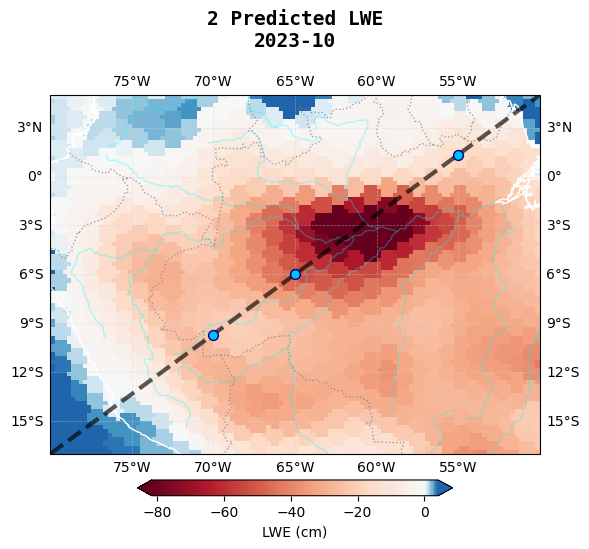

In [ ]:
# Subplot raw_predict
models_dir = "../models/"
var_to_plot = "lwe_thickness"

# Select trained Model
print(f"\nScanning directory: {models_dir} ")
try:
    available_models = [f for f in os.listdir(models_dir) if f.endswith(".pkl")]
    if not available_models:
        print(Fore.RED + " Error: No .pkl files found in the models directory!")
        sys.exit()
# comment 
    print(" Available Models:")
    for i, model_file in enumerate(available_models):
        print(f"  [{i+1}] {model_file}")

    try:
        selection = int(input(f"\nSelect Model Number (1-{len(available_models)}): "))
        if 1 <= selection <= len(available_models):
            selected_model_name = available_models[selection - 1]
            full_model_path = os.path.join(models_dir, selected_model_name)
            print(f"  Selected: {selected_model_name}")
        else:
            print(Fore.RED + "  Invalid number selected. Exiting.")
            sys.exit()
    except ValueError:
        print(Fore.RED +"  Invalid input. Please enter a number.")
        sys.exit()

except FileNotFoundError:
    print(Fore.RED + f"  Error: Directory '{models_dir}' not found.")
    sys.exit()

# Load the chosen model
print(" Loading model...")
model = joblib.load(full_model_path)

try:
    basin_name = input("Enter Basin Name for the Title (e.g. Amazon, Lake Victoria): ").strip()
except ValueError:
    print(Fore.RED +" Invalid input! Terminating programm.")
    sys.exit()

# input date
try:
    map_year = int(input("Enter year: "))
    map_month = int(input("Enter month: "))
except ValueError:
    print(Fore.RED +" Invalid input! Terminating programm.")
    sys.exit()

target_ym = f"{map_year}-{map_month:02d}"

# Dynamic .jpg title approach
output_jpg_grace = f"../results/Comparison_GRACE_{basin_name}_{target_ym}_{selected_model_name}.jpg"
# Solving overwrite output problem 
i=1
while os.path.exists(output_jpg_grace):
    output_jpg_grace = f"../results/Comparison_GRACE_{basin_name}_{target_ym}_{selected_model_name}_{i}.jpg"
    i=i+1
else:
    print(f"Map saved to {output_jpg_grace}")
    
# -------------------------
# GRACE raw data (mask by year/month)
# -------------------------
t_index = pd.DatetimeIndex(ds_grace_sliced.time.values)
mask = (t_index.year == map_year) & (t_index.month == map_month)

if not mask.any():
    print(Fore.RED + f" Error: Grace data not found for {target_ym}")
    sys.exit()

# If there are multiple timestamps in the same month, pick the first
idx = int(np.where(mask)[0][0])

data_actual = ds_grace_sliced[var_to_plot].isel(time=idx)
picked_ts = pd.Timestamp(data_actual.time.values)
time_str = picked_ts.strftime("%Y-%m")

# -------------------------
# ERA5 data after prediction
# -------------------------
input_ERA_data = era5_df[(era5_df["year"] == map_year) & (era5_df["month"] == map_month)].copy()

if input_ERA_data.empty:
    print(Fore.RED + f" Error: ERA5 data not found for {target_ym}.")
    sys.exit()
else:
    try:
        required_features = model.feature_names_in_
    except AttributeError:
        print("Using default features")
        required_features = features

    missing_feats = [c for c in required_features if c not in input_ERA_data.columns]
    if missing_feats:
        raise KeyError(f"Missing required features in ERA5 input_data: {missing_feats}")

    X_pred = input_ERA_data[required_features]
    input_ERA_data["lwe_pred"] = model.predict(X_pred)

    ds_pred = input_ERA_data.groupby(["lat", "lon"])[["lwe_pred"]].mean().to_xarray()
    data_predicted = ds_pred["lwe_pred"]

#
# Plot
# 1. Get raw bounds
vmin = data_actual.quantile(0.02).item()
vmax = data_actual.quantile(0.98).item()

# Safety catch for zero crossing
vmin = min(vmin, -0.1)
vmax = max(vmax, 0.1)

# 2. Calculate the normalized position of zero
zero_pos = (0 - vmin) / (vmax - vmin)

# 3. Start with the original colormap
orig_cmap = plt.get_cmap("RdBu")

# 4. Extract the exact color arrays
n_neg = int(256 * zero_pos)
n_pos = 256 - n_neg

# For the negative side: Grab the EXACT rich reds from the original colormap (0.0 to 0.5)
colors_neg = orig_cmap(np.linspace(0.0, 0.5, n_neg))

# For the positive side: Grab the blues, boosting the end point to 0.9 to make it pop (0.5 to 0.9)
colors_pos = orig_cmap(np.linspace(0.5, 0.9, n_pos))

# Combine the two halves
all_colors = np.vstack((colors_neg, colors_pos))

# 5. Create the new colormap from the high-res array
boosted_rdbu = mcolors.LinearSegmentedColormap.from_list("boosted_rdbu", all_colors)

fig, ax = plt.subplots(
        figsize=(6, 6), 
        subplot_kw={"projection": ccrs.PlateCarree()})

mesh = data_actual.plot.pcolormesh(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap=boosted_rdbu,
            vmin=vmin,           
            vmax=vmax,
            extend="both",
            cbar_kwargs={"label": "LWE (cm)", "orientation": "horizontal", "pad": 0.05, "fraction": 0.03, "spacing": "proportional"},
        )

# 4. Add geographic features
ax.set_title(f"{basin_name} Predicted LWE\n{time_str}", fontsize=14, fontfamily='monospace', fontweight="bold", pad=20)
ax.coastlines(resolution="10m", color="white", linewidth=1)
ax.add_feature(cfeature.BORDERS, linestyle=":", edgecolor='gray', alpha=0.7)
ax.add_feature(cfeature.RIVERS, color="cyan", alpha=0.3)

# 5. Configure gridlines with labels
gl = ax.gridlines(
    draw_labels=True, 
    linewidth=0.5, 
    linestyle="--", 
    alpha=0.5, 
    color='lightgray'
)
#extras 
# Define start and end of the line (lon, lat)
line_lons = [-80, -50]
line_lats = [-17, 5]

ax.plot(
    line_lons,
    line_lats,
    transform=ccrs.PlateCarree(),
    color="black",
    linewidth=3,
    linestyle='--', 
    zorder=10,
    alpha=0.65
)

point_lons = [-70, -65, -55]
point_lats = [-9.7, -6, 1.3]

# Plot red points
ax.scatter(
    point_lons,
    point_lats,
    transform=ccrs.PlateCarree(),
    facecolor='deepskyblue',
    edgecolor='navy',
    s=45,
    marker='o',
    zorder=11
)

plt.tight_layout()
plt.show()